In [ ]:
import os
import shutil

import matplotlib.pyplot as plt
%env NX_CUGRAPH_AUTOCONFIG=True
import networkx as nx
#import nx_cugraph as nxcg
#import cudf
#import cugraph
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import cliquematch
import math



import random

if os.path.exists('generated_graphs'):
    shutil.rmtree('generated_graphs')  # Supprime tout le dossier et son contenu
os.makedirs('generated_graphs', exist_ok=True)  # Recrée un répertoire vide

In [ ]:
def generate_random_bipartite_graph(n):
    partition_size = n // 2
    remainder = n % 2

    G = nx.bipartite.random_graph(partition_size, partition_size + remainder, 0.5)
    
    adj_matrix = nx.to_numpy_array(G)
    if adj_matrix.shape != (n, n):
        adj_matrix = np.pad(adj_matrix, ((0, n - adj_matrix.shape[0]), (0, n - adj_matrix.shape[1])), mode='constant')
    
    return adj_matrix

def generate_random_planar_graph(n):
    side_length = int(np.ceil(np.sqrt(n)))
    
    G = nx.grid_2d_graph(side_length, side_length)
    
    # Convertir les nœuds de la grille en un seul index
    mapping = {node: i for i, node in enumerate(G.nodes())}
    G = nx.relabel_nodes(G, mapping)
    
    # Si le nombre de nœuds est supérieur à n, supprimer les nœuds supplémentaires
    if len(G.nodes()) > n:
        nodes_to_remove = list(G.nodes())[n:]
        G.remove_nodes_from(nodes_to_remove)
    
    # Ajouter des arêtes aléatoires tout en vérifiant que le graphe reste planaire
    possible_edges = [(u, v) for u in range(n) for v in range(u + 1, n) if not G.has_edge(u, v)]
    np.random.shuffle(possible_edges)
    
    for u, v in possible_edges:
        G.add_edge(u, v)
        if not nx.check_planarity(G)[0]:
            G.remove_edge(u, v)
    
    adj_matrix = nx.to_numpy_array(G)
    
    return adj_matrix

def generate_random_cyclic_graph(n):
    G = nx.Graph()  # Créer un graphe non orienté
    G.add_nodes_from(range(n))

    # Ajouter des arêtes pour créer un cycle
    edges = [(i, (i + 1) % n) for i in range(n)]  # Cycle de base
    G.add_edges_from(edges)

    # Ajouter des arêtes supplémentaires aléatoires pour augmenter la complexité
    while len(G.edges) < n + np.random.randint(1, n): 
        u, v = np.random.choice(n, 2, replace=False)
        G.add_edge(u, v)

    return nx.to_numpy_array(G)

def generate_random_cycle_graph(n):
    G = nx.Graph()
    G.add_nodes_from(range(n))
    
    # Mélanger les sommets de manière aléatoire
    nodes = list(G.nodes())
    np.random.shuffle(nodes)
    
    # Ajouter des arêtes pour former un cycle
    edges = [(nodes[i], nodes[(i + 1) % n]) for i in range(n)]
    G.add_edges_from(edges)
    
    adj_matrix = nx.to_numpy_array(G)
    
    return adj_matrix

def generate_random_binary_tree(n):
    G = nx.DiGraph()  # Graphe orienté
    G.add_node(0)  # Ajouter la racine
    for i in range(1, n):
        parent = np.random.randint(0, i)  # Choisir un parent aléatoire
        # S'assurer que le parent n'a pas déjà deux enfants
        while G.out_degree(parent) >= 2:
            parent = np.random.randint(0, i)
        G.add_node(i)  # Ajouter le nœud
        G.add_edge(parent, i)  # Créer une arête orientée du parent vers l'enfant
    return nx.to_numpy_array(G)

def generate_random_tree(n):
    G = nx.Graph()
    G.add_nodes_from(range(n))
    
    # Ajouter des arêtes pour la connexité
    for i in range(1, n):
        u = np.random.randint(0, i)
        G.add_edge(u, i)
    
    # Ajouter des arêtes supplémentaires aléatoires pour augmenter la complexité
    num_edges = np.random.randint(n - 1, n * (n - 1) // 2)  # Nombre d'arêtes entre n-1 et n*(n-1)/2 (graphe complet)
    while G.number_of_edges() < num_edges:
        u, v = np.random.choice(n, 2, replace=False)
        if not G.has_edge(u, v):
            G.add_edge(u, v)
    
    T = nx.minimum_spanning_tree(G, algorithm='boruvka')
    
    adj_matrix = nx.to_numpy_array(T)
    if adj_matrix.shape != (n, n):
        adj_matrix = np.pad(adj_matrix, ((0, n - adj_matrix.shape[0]), (0, n - adj_matrix.shape[1])), mode='constant')
    
    return adj_matrix

def generate_random_clique_graph(n):
    G = nx.Graph()
    nodes = list(range(n))
    random.shuffle(nodes)
    
    num_cliques = int(math.ceil(3 ** (n / 3)))
    clique_sizes = [random.randint(2, len(nodes) // num_cliques) for _ in range(num_cliques)]
    
    for clique_size in clique_sizes:
        if len(nodes) < clique_size:
            clique_size = len(nodes)
        clique_nodes = nodes[:clique_size]
        nodes = nodes[clique_size:]
        
        G.add_nodes_from(clique_nodes)
        for u in clique_nodes:
            for v in clique_nodes:
                if u != v:
                    G.add_edge(u, v)
    
    # If there are remaining nodes, add them to existing cliques randomly
    while nodes:
        node = nodes.pop()
        clique = random.choice(list(G.nodes))
        G.add_edge(node, clique)
    
    # Add some random edges to ensure the graph is not just a collection of cliques
    num_random_edges = random.randint(1, n)  # Adjust the number of random edges as needed
    all_nodes = list(G.nodes)
    for _ in range(num_random_edges):
        u, v = random.sample(all_nodes, 2)
        if not G.has_edge(u, v):
            G.add_edge(u, v)
    
    adj_matrix = nx.to_numpy_array(G)
    if adj_matrix.shape != (n, n):
        adj_matrix = np.pad(adj_matrix, ((0, n - adj_matrix.shape[0]), (0, n - adj_matrix.shape[1])), mode='constant')
    
    return adj_matrix
# Enregistrer les graphes dans le dataset
def save_graphs(graph_dataset, n_graphs, n_nodes):
    for i in range(n_graphs):
        adj_matrix = graph_dataset[i].reshape(n_nodes, n_nodes)
        G = nx.from_numpy_array(adj_matrix)
        
        # Créer un fichier d'image pour chaque graphe
        if i % 10_000 == 0:
            plt.figure(figsize=(8, 6))
            try:
                nx.draw_planar(G, with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
            except nx.NetworkXException:
                # Si le graphe n'est pas planaire, utiliser un autre layout
                nx.draw(G, with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
            
            plt.title(f"Graphe {i + 1}")
            plt.show()

        # Enregistrer l'image dans le dossier 'generated_graphs'
        #plt.savefig(f'generated_graphs/graph_{i + 1}.png')
        plt.close()  # Fermer la figure pour libérer de la mémoire

In [ ]:
class DegreeLayer(nn.Module):
    def _init_(self, n_nodes):
        super(DegreeLayer, self)._init_()
        self.n_nodes = n_nodes
        self.sum_layer = nn.Linear(n_nodes, 1, bias=False)
        #Figer les poids à 1
        self.sum_layer.weight.data.fill_(1)
        self.sum_layer.weight.requires_grad = False
        
    def forward(self, adj_matrix):
        batch_size = adj_matrix.size(0)
        degrees = torch.zeros(batch_size, self.n_nodes).to(adj_matrix.device)
        for i in range(self.n_nodes):
            degrees[:, i] = self.sum_layer(adj_matrix[:, i, :]).squeeze()
        return degrees

class Generator(nn.Module):
    def __init__(self, n_nodes):
        super(Generator, self).__init__()
        self.n_nodes = n_nodes
        self.fc = nn.Sequential(
            nn.Linear(n_nodes, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, n_nodes * n_nodes)
        )

    def forward(self, z):
        output = self.fc(z)
        adj_matrix = output.view(-1, self.n_nodes, self.n_nodes)
        adj_matrix = (adj_matrix + adj_matrix.transpose(1, 2)) / 2
        adj_matrix = torch.sigmoid(adj_matrix)
        adj_matrix = adj_matrix * (1 - torch.eye(self.n_nodes)).to(adj_matrix.device)
        #adj_matrix = (adj_matrix > 0.5).float()
        return adj_matrix

class Discriminator(nn.Module):
    def __init__(self, n_nodes):
        super(Discriminator, self).__init__()
        self.n_nodes = n_nodes
        self.fc = nn.Sequential(
            nn.Linear(n_nodes * n_nodes, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, adj_matrix):
        x = adj_matrix.view(-1, self.n_nodes * self.n_nodes)
        return self.fc(x)

In [ ]:
def binary_tree_loss(adj_matrix):
    batch_size, n_nodes, _ = adj_matrix.size()
    
    degrees = torch.sum(adj_matrix, dim=2)
    degree_penalty = torch.sum(torch.sum(F.relu(degrees - 3.0) ** 2, dim=1), dim=0)
    
    connectivity = torch.zeros(adj_matrix.size(0)).to(adj_matrix.device)
    for i in range(adj_matrix.size(0)):
        G = nx.from_numpy_array(adj_matrix[i].detach().cpu().numpy())
        num_components = nx.number_connected_components(G)
        
        connectivity[i] = num_components
    loss_connexe = torch.sum((connectivity-1)**2)
    
    n_moins_1_penalty = torch.sum(degrees, dim=1)
    n_moins_1_penalty = torch.sum(torch.sum(n_moins_1_penalty - (n_nodes-1))**2)
    
    return degree_penalty + loss_connexe + n_moins_1_penalty,n_moins_1_penalty
def simple_from_numpy_array(A):
    """Convert a 2D NumPy array to a NetworkX graph.

    Parameters
    ----------
    A : 2D numpy.ndarray
        An adjacency matrix representation of a graph.

    Returns
    -------
    G : NetworkX Graph
        A NetworkX graph generated from the adjacency matrix.
    """
    G = nx.Graph()
    n, m = A.shape
    if n != m:
        raise nx.NetworkXError("Adjacency matrix is not square.")
    
    G.add_nodes_from(range(n))
    edges = zip(*np.nonzero(A))
    G.add_edges_from((u, v, {'weight': A[u, v]}) for u, v in edges)
    
    return G








def degree_loss(adj_matrix):
    degrees = torch.sum(adj_matrix, dim=2)
    degree_penalty = torch.sum(torch.sum((degrees - 2.0) ** 2, dim=1), dim=0)
    
    # Initialize the penalty for disconnected graphs
    connectivity = torch.zeros(adj_matrix.size(0)).to(adj_matrix.device)
    
    # Calculate the number of connected components for each graph
    for i in range(adj_matrix.size(0)):
        G = nx.from_numpy_array(adj_matrix[i].detach().cpu().numpy())
        num_components = nx.number_connected_components(G)
        
        connectivity[i] = num_components
    
    loss_connexe = torch.sum((connectivity-1)**2)
    total_penalty = degree_penalty + loss_connexe
    
    return total_penalty#,torch.sum((connectivity-1)**2)

def tree_loss(adj_matrix):
    connectivity = torch.zeros(adj_matrix.size(0)).to(adj_matrix.device)
    
    matrice = (adj_matrix>0.5).float() + adj_matrix - adj_matrix.detach()
    for i in range(adj_matrix.size(0)):

        
        G = nx.from_numpy_array(matrice[i].detach().cpu().numpy())
        num_components = nx.number_connected_components(G)
        
        connectivity[i] = num_components
    
    loss_connexe = torch.sum((connectivity-1)**2)

    degrees = torch.sum(adj_matrix, dim=2)
    somme_deg=torch.sum(degrees,dim=1)
    somme_deg_loss=torch.sum(torch.sum((somme_deg-2*(n_nodes-1))**2,dim=0))

    return loss_connexe + somme_deg_loss, loss_connexe

def bipartite_loss(adj_matrix):#ne marche pas encore
    batch_size, n_nodes, _ = adj_matrix.size()
    total_loss = torch.zeros(batch_size).to(adj_matrix.device)
    for i in range(batch_size):
        # Utiliser le straight-through estimator
        matrice = (adj_matrix[i] > 0.5).float() + adj_matrix[i] - adj_matrix[i].detach()
        
        # Convertir la matrice d'adjacence en un graphe NetworkX
        G = nx.from_numpy_array(matrice.detach().cpu().numpy())
        try:
            # Trouver les cycles dans le graphe
            cycles = nx.find_cycle(G)
            
            # Calculer la perte basée sur les arêtes qui forment les cycles
            cycle_loss = 0
            for u, v in cycles:
                cycle_loss += adj_matrix[i, u, v]
            
            total_loss[i] = cycle_loss ** 2
        except nx.NetworkXNoCycle:
            # Si aucun cycle n'est trouvé, pénaliser le graphe
            total_loss[i] = 0.0
        degrees = torch.sum(matrice, dim=1)
        degree_penalty = torch.sum((degrees < 1).float())
        
        total_loss[i] += degree_penalty
    
    
    return torch.sum(total_loss), torch.sum(total_loss)

def maximal_cliquematch_time_loss(adj_matrix):
    batch_size, n_nodes, _ = adj_matrix.size()
    total_loss = torch.zeros(batch_size).to(adj_matrix.device)
    time_loss = torch.zeros(batch_size).to(adj_matrix.device)
    for i in range(batch_size):

        matrice = (adj_matrix[i] > 0.5).float() + adj_matrix[i] - adj_matrix[i].detach()

        G = cliquematch.from_matrix(matrice.detach().cpu().numpy())
        start_time = time.time()
        G.get_max_clique(use_heuristic = False)
        end_time = time.time()
        time_loss[i] = end_time - start_time
    time_loss = -torch.sum(time_loss)
    return time_loss, time_loss


def maximal_clique_time_loss(adj_matrix):
    batch_size, n_nodes, _ = adj_matrix.size()
    total_loss = torch.zeros(batch_size).to(adj_matrix.device)
    time_loss = torch.zeros(batch_size).to(adj_matrix.device)
    for i in range(batch_size):
        # Utiliser le straight-through estimator
        matrice = (adj_matrix[i] > 0.5).float() + adj_matrix[i] - adj_matrix[i].detach()
        # Convertir la matrice d'adjacence en un graphe NetworkX
        G = nx.from_numpy_array(matrice.detach().cpu().numpy())
        
        start_time = time.time()
        # Trouver les cycles dans le graphe
        maximal_cliques = nx.find_cliques(G)
        end_time = time.time()
        # Calculer la perte basée sur les arêtes qui forment les cycles
        time_loss[i] = end_time - start_time
    time_loss = -torch.sum(time_loss)
    return time_loss, time_loss

In [ ]:
def train(n_nodes=10, n_graphs=256, num_epochs=10_000, batch_size=32, fct=generate_random_cycle_graph):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(device)
    
    graph_dataset = [fct(n_nodes) for _ in range(n_graphs)]
    
    generator = Generator(n_nodes).to(device)
    discriminator = Discriminator(n_nodes).to(device)
    
    g_optimizer = optim.Adam(generator.parameters(), lr=0.0001)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0001)
    if fct==generate_random_cycle_graph:
        aux_loss = degree_loss
    elif fct==generate_random_binary_tree:
        print("binary tree")
        aux_loss = binary_tree_loss
    elif fct==generate_random_tree:
        print("tree")
        aux_loss = tree_loss
    elif fct==generate_random_bipartite_graph:
        print("bipartite")
        aux_loss = bipartite_loss
    for epoch in range(num_epochs):
        start_timeg = time.time()
        for i in range(0, n_graphs, batch_size):
            #real_graphs = torch.tensor(graph_dataset[i:i+batch_size], dtype=torch.float32).to(device)
            start_timeg = time.time()
            batch_graphs_np = np.array(graph_dataset[i:i+batch_size])
            real_graphs = torch.tensor(batch_graphs_np, dtype=torch.float32).to(device)

            
            
            z = torch.randn(batch_size, n_nodes).to(device)
            
            fake_adj = generator(z)
            

            d_optimizer.zero_grad()
            d_real = discriminator(real_graphs)
            d_fake = discriminator(fake_adj.detach())
            d_loss = -torch.mean(torch.log(d_real) + torch.log(1 - d_fake))
            d_loss.backward()
            d_optimizer.step()
            
            g_optimizer.zero_grad()
            g_fake = discriminator(fake_adj)
            gen_time = time.time() - start_timeg  
            start_time = time.time()
            custom_loss, n_moins_1 = aux_loss(fake_adj)
            loss_time = time.time() - start_time
            
            g_loss = -torch.mean(torch.log(1-g_fake)) + custom_loss
            g_loss.backward()
            g_optimizer.step()
            
            
        if epoch % 1 == 0:
            print(f'Epoch [{epoch}/{num_epochs}], d_loss: {d_loss.item()}, g_loss: {g_loss.item()}, aux_loss: {custom_loss.item()}, g_without_aux_loss: {g_loss.item() - custom_loss.item()}, n_moins_1_penalty: {n_moins_1.item()}')
            print(f'Time for generator: {gen_time:.4f}s, Time for tree_loss: {loss_time:.4f}s')
            torch.save(generator.state_dict(), 'generator_cycle2.pth')
            torch.save(discriminator.state_dict(), 'discriminator_cycle.pth')
n_nodes = 10
train(n_nodes=n_nodes, n_graphs=1024, num_epochs=350, batch_size=32, fct=generate_random_tree)

def visualize_generated_graphs(generator, n_samples=5, n_nodes=10):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, n_nodes)
        fake_adj = (generator(z)>0.5).float()
        
        for i in range(n_samples):
            adj_matrix = fake_adj[i].numpy()
            G = nx.from_numpy_array(adj_matrix)
            degrees = torch.sum(fake_adj[i], dim=1).numpy().round(2)
            
            plt.figure(figsize=(8, 6))
            nx.draw(G, with_labels=True, node_color='lightblue', 
                   node_size=500, font_size=16, font_weight='bold')
            plt.title(f'Generated Graph {i+1}\nNode Degrees: {degrees}')
            plt.show()

generator = Generator(n_nodes=n_nodes)

generator.load_state_dict(torch.load('generator_cycle2.pth'))

visualize_generated_graphs(generator, n_samples=5, n_nodes=n_nodes)

env: NX_CUGRAPH_AUTOCONFIG=True
cuda
tree
Epoch [0/350], d_loss: 1.2552268505096436, g_loss: 17572.189453125, aux_loss: 17571.732421875, g_without_aux_loss: 0.45703125, n_moins_1_penalty: 19.0
Time for generator: 0.0062s, Time for tree_loss: 1.1269s
Epoch [1/350], d_loss: 1.177407145500183, g_loss: 14116.6279296875, aux_loss: 14116.236328125, g_without_aux_loss: 0.3916015625, n_moins_1_penalty: 467.0
Time for generator: 0.0079s, Time for tree_loss: 0.9240s
Epoch [2/350], d_loss: 1.1153508424758911, g_loss: 11517.9365234375, aux_loss: 11517.5751953125, g_without_aux_loss: 0.361328125, n_moins_1_penalty: 1069.0
Time for generator: 0.0070s, Time for tree_loss: 0.7236s
Epoch [3/350], d_loss: 1.0564749240875244, g_loss: 10011.4716796875, aux_loss: 10011.1259765625, g_without_aux_loss: 0.345703125, n_moins_1_penalty: 1785.0
Time for generator: 0.0052s, Time for tree_loss: 0.3800s
Epoch [4/350], d_loss: 0.9998166561126709, g_loss: 8398.0673828125, aux_loss: 8397.732421875, g_without_aux_loss:

In [1]:
1.188**100

30314057.113799516

In [26]:
1.2108**100

202880930.6795489

In [3]:
1.4422**100

7990043109069350.0

In [ ]:
def generate_random_clique_graph(n):
    G = nx.Graph()
    nodes = list(range(n))
    random.shuffle(nodes)
    
    num_cliques = int(math.ceil(3 ** (n / 3)))
    clique_sizes = [random.randint(2, len(nodes) // num_cliques) for _ in range(num_cliques)]
    
    for clique_size in clique_sizes:
        if len(nodes) < clique_size:
            clique_size = len(nodes)
        clique_nodes = nodes[:clique_size]
        nodes = nodes[clique_size:]
        
        G.add_nodes_from(clique_nodes)
        for u in clique_nodes:
            for v in clique_nodes:
                if u != v:
                    G.add_edge(u, v)
    
    #Ajouter les derniers sommets restants
    while nodes:
        node = nodes.pop()
        clique = random.choice(list(G.nodes))
        G.add_edge(node, clique)
    
    #Ajouter quelques arêtes aléatoires pour éviter que une clique=composante connexe
    num_random_edges = random.randint(1, n)
    all_nodes = list(G.nodes)
    for _ in range(num_random_edges):
        u, v = random.sample(all_nodes, 2)
        if not G.has_edge(u, v):
            G.add_edge(u, v)
    
    adj_matrix = nx.to_numpy_array(G)
    if adj_matrix.shape != (n, n):
        adj_matrix = np.pad(adj_matrix, ((0, n - adj_matrix.shape[0]), (0, n - adj_matrix.shape[1])), mode='constant')
    
    return adj_matrix
for i in range(5):
    G, adj_matrix = generate_random_clique_graph(n)
    print(f"Graphe {i+1} - Matrice d'adjacence :\n", adj_matrix)
    
    # Afficher le graphe avec Matplotlib
    plt.figure(figsize=(6, 4))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True)
    plt.title(f"Graphe {i+1}")
    plt.show()

5 4
2 1
8 7


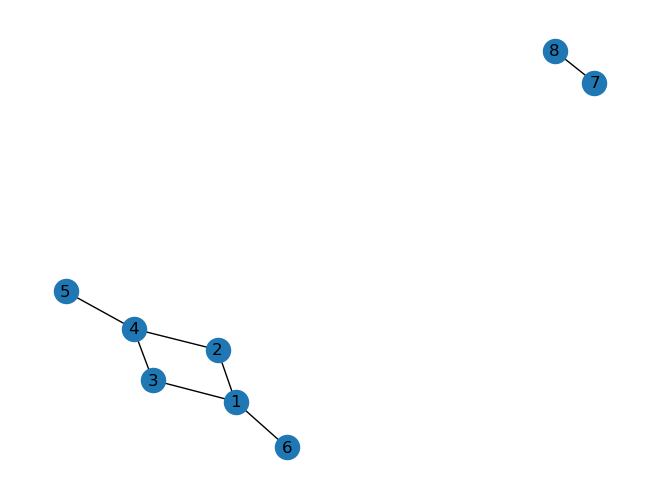

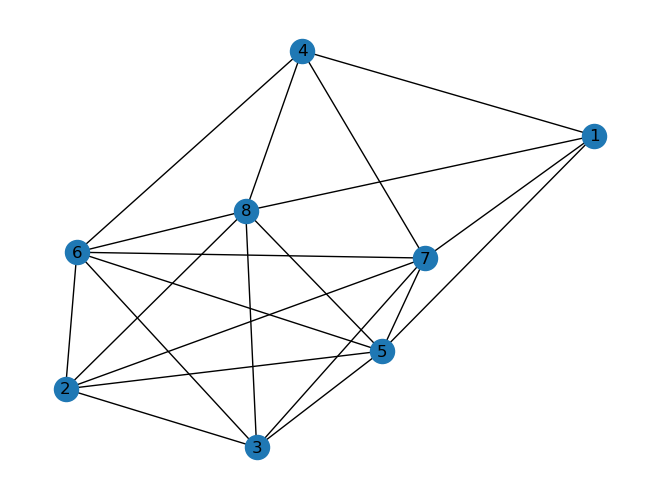

Taille du Maximum Independent Set: 5
Nœuds du Maximum Independent Set: {2, 3, 5, 6, 8}


In [ ]:
import networkx as nx


def find_mirrors(G, v):
    N_v = set(G.neighbors(v))
    N2_v = set(nx.single_source_shortest_path_length(G, v, cutoff=2).keys()) - N_v - {v}
    mirrors = set()
    for u in N2_v:
        N_v_minus_N_u = N_v - set(G.neighbors(u))
        if all(G.has_edge(x, y) for x in N_v_minus_N_u for y in N_v_minus_N_u if x != y):
            mirrors.add(u)
    return mirrors

def fold_node(G, v):
    neighbors = list(G.neighbors(v))
    anti_edges = [(u, w) for i, u in enumerate(neighbors) for w in neighbors[i+1:] if not G.has_edge(u, w)]
    
    #Ajouter u_ij à chaque anti-edge u_i u_j de N(v)
    new_nodes = {}
    for u, w in anti_edges:
        new_node = f"{u}_{w}"
        G.add_node(new_node)
        new_nodes[(u, w)] = new_node
    
    #Add edges between each u_ij and the nodes in N(u_i) ∪ N(u_j)
    for (u, w), new_node in new_nodes.items():
        neighbors_u_w = set(G.neighbors(u)).union(set(G.neighbors(w)))
        for neighbor in neighbors_u_w:
            G.add_edge(new_node, neighbor)
    
    #Ajouter une arrête entre chaque nouvelle paire de sommets
    new_node_list = list(new_nodes.values())
    for i in range(len(new_node_list)):
        for j in range(i + 1, len(new_node_list)):
            G.add_edge(new_node_list[i], new_node_list[j])
    
    #Supprimer N[v]=N(v)∪{v}
    G.remove_nodes_from(neighbors)
    G.remove_node(v)
    
    return G


def mis(G):
    if G.number_of_nodes() == 0:
        return 0, set()
    
    #Connected components
    if nx.number_connected_components(G) > 1:
        total_mis = 0
        total_nodes = set()
        components = list(nx.connected_components(G))
        for c in components:
            subgraph = G.subgraph(c).copy()
            subgraph_mis, subgraph_nodes = mis(subgraph)
            total_mis += subgraph_mis
            total_nodes.update(subgraph_nodes)
        return total_mis, total_nodes
    
    #Node domination
    for v in G.nodes():
        for w in G.nodes():
            if v != w and set(G.neighbors(v)).union({v}).issubset(set(G.neighbors(w)).union({w})):
                H = G.copy()
                print(v,w)
                H.remove_node(w)
                return mis(H)
    
    #Foldable node
    for v in G.nodes():
        neighbors = list(G.neighbors(v))
        if len(neighbors) <= 4:
            anti_edges = 0
            for i in range(len(neighbors)):
                for j in range(i + 1, len(neighbors)):
                    if not G.has_edge(neighbors[i], neighbors[j]):
                        anti_edges += 1
            if anti_edges <= 3:
                H = fold_node(G.copy(), v)
                sub_mis, sub_nodes = mis(H)
                return 1 + sub_mis, sub_nodes.union({v})
    
    #v est le sommet de degré maximal
    v = max(G.nodes(), key=G.degree)
    mirrors = find_mirrors(G, v)
    H1 = G.copy()
    H1.remove_node(v)
    H1.remove_nodes_from(mirrors)
    H2 = G.copy()
    H2.remove_node(v)
    H2.remove_nodes_from(list(G.neighbors(v)))
    
    mis1, nodes1 = mis(H1)
    mis2, nodes2 = mis(H2)
    
    if mis1 > 1 + mis2:
        return mis1, nodes1
    else:
        return 1 + mis2, nodes2.union({v})


G = nx.Graph()
G.add_edges_from([(1, 2), (1, 3), (2, 4), (3, 4), (4, 5), (1,6), (7,8)])
mis_size, mis_nodes = mis(G)
nx.draw(G, with_labels=True)
plt.show()
nx.draw(nx.complement(G), with_labels=True)
plt.show()
print("Taille du Maximum Independent Set:", mis_size)
print("Nœuds du Maximum Independent Set(maximum clique du deuxième graphe affiché):", mis_nodes)